<a href="https://colab.research.google.com/github/peperjet/bc-ml/blob/main/dacon/wine3_del.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

와인 품질(Quality)분류 경진대회
https://www.dacon.io/competitions/open/235610/overview/description

In [ ]:
# 라이브러리 로딩
import pandas as pd
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt


# 경고 메세지 숨기기
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# 데이터 불러오기
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

간단한 EDA

In [ ]:
# train 데이터의 개형을 살펴봅니다
# index를 제외하면 총 13개 변수를 가집니다.

train.head()

,index,quality,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,0,5,5.6,0.695,0.06,6.8,0.042,9.0,84.0,0.99432,3.44,0.44,10.2,white
1,1,5,8.8,0.610,0.14,2.4,0.067,10.0,42.0,0.99690,3.19,0.59,9.5,red
2,2,5,7.9,0.210,0.39,2.0,0.057,21.0,138.0,0.99176,3.05,0.52,10.9,white
3,3,6,7.0,0.210,0.31,6.0,0.046,29.0,108.0,0.99390,3.26,0.50,10.8,white
4,4,6,7.8,0.400,0.26,9.5,0.059,32.0,178.0,0.99550,3.04,0.43,10.9,white


- index : 구분자
- quality : 품질
- fixed acidity : 산도
- volatile acidity : 휘발성산
- citric acid : 시트르산
- residual sugar 잔당 : 발효 후 와인 속에 남아있는 당분
- chlorides : 염화물
- free sulfur dioxide : 독립 이산화황
- total sulfur dioxide : 총 이산화황
- density : 밀도
- pH : 수소이온농도
- sulphates : 황산염
- alcohol : 도수
- type : 종류



In [ ]:
# test 데이터의 개형을 살펴봅니다
# index를 제외하면 총 12개 변수를 가집니다.
# train 중 quality 변수가 사라졌습니다.
test.head()

,index,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,0,9.0,0.31,0.48,6.6,0.043,11.0,73.0,0.99380,2.90,0.38,11.6,white
1,1,13.3,0.43,0.58,1.9,0.070,15.0,40.0,1.00040,3.06,0.49,9.0,red
2,2,6.5,0.28,0.27,5.2,0.040,44.0,179.0,0.99480,3.19,0.69,9.4,white
3,3,7.2,0.15,0.39,1.8,0.043,21.0,159.0,0.99480,3.52,0.47,10.0,white
4,4,6.8,0.26,0.26,2.0,0.019,23.5,72.0,0.99041,3.16,0.47,11.8,white


In [ ]:
# tain 데이터의 열 별 정보를 살펴봅니다.
# 결측치는 없습니다
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5497 entries, 0 to 5496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 5497 non-null   int64  
 1   quality               5497 non-null   int64  
 2   fixed acidity         5497 non-null   float64
 3   volatile acidity      5497 non-null   float64
 4   citric acid           5497 non-null   float64
 5   residual sugar        5497 non-null   float64
 6   chlorides             5497 non-null   float64
 7   free sulfur dioxide   5497 non-null   float64
 8   total sulfur dioxide  5497 non-null   float64
 9   density               5497 non-null   float64
 10  pH                    5497 non-null   float64
 11  sulphates             5497 non-null   float64
 12  alcohol               5497 non-null   float64
 13  type                  5497 non-null   object 
dtypes: float64(11), int64(2), object(1)
memory usage: 601.4+ KB


<Axes: >

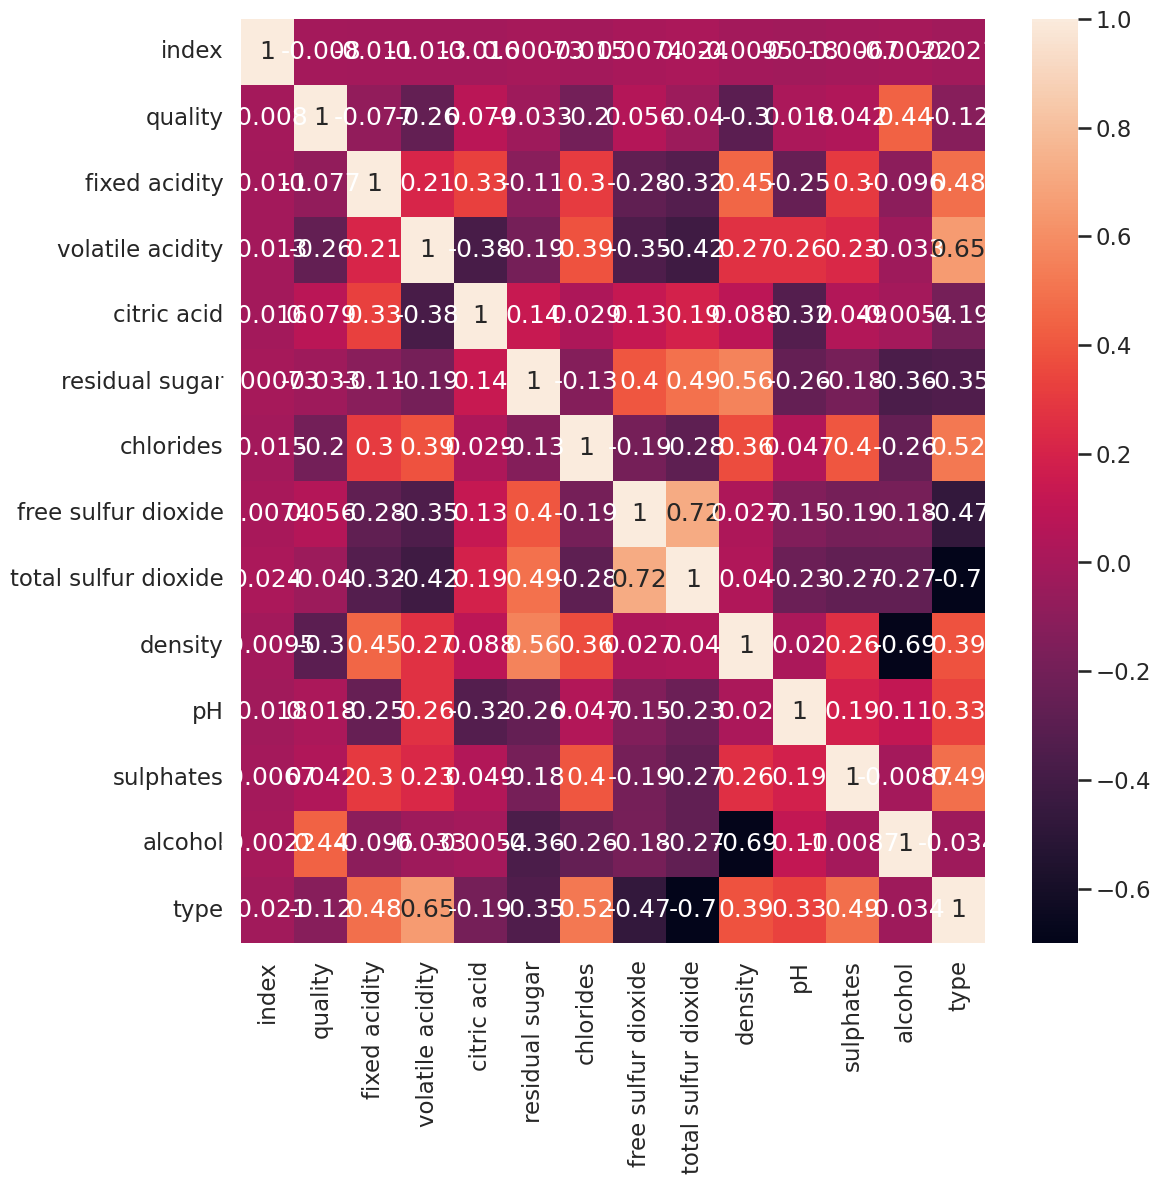

In [ ]:
# train의 변수 간 상관관계를 살펴봅니다.
# 'type' 컬럼을 숫자로 변환합니다 (예: white=0, red=1)
train_corr = train.copy()
train_corr['type'] = train_corr['type'].map({'white': 0, 'red': 1})

plt.figure(figsize=(12,12))
sns.heatmap(data = train_corr.corr(), annot=True)

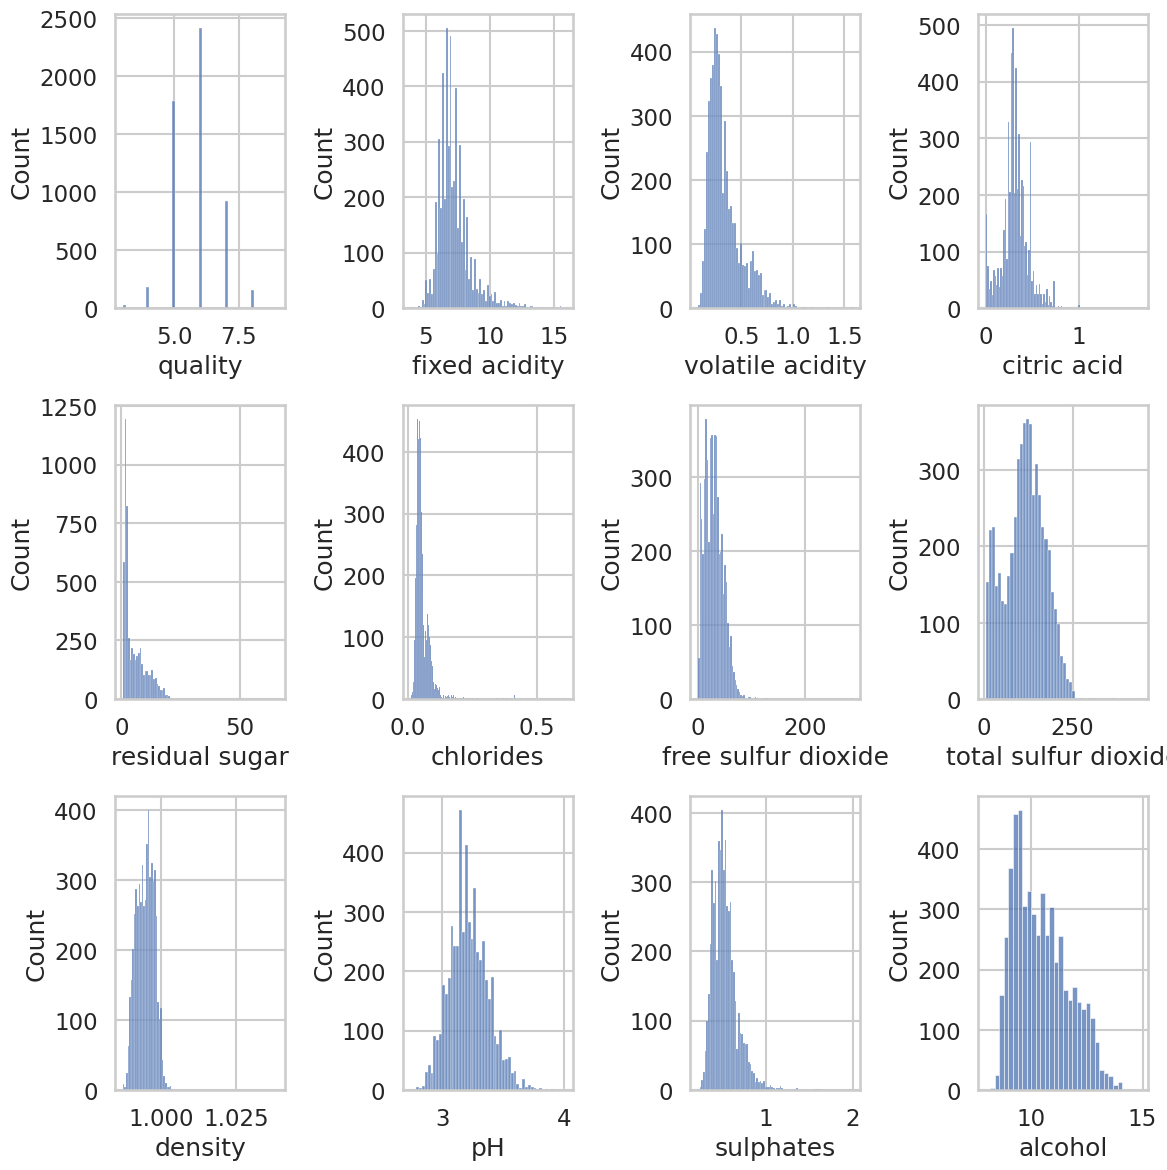

In [ ]:
# train의 각 변수별 분포를 살펴보자
plt.figure(figsize=(12,12))
for i in range(1,13):
    plt.subplot(3,4,i)
    sns.histplot(train.iloc[:,i]) # 데이터가 어떻게 퍼져있는지 보여주는 함수

plt.tight_layout()
plt.show()

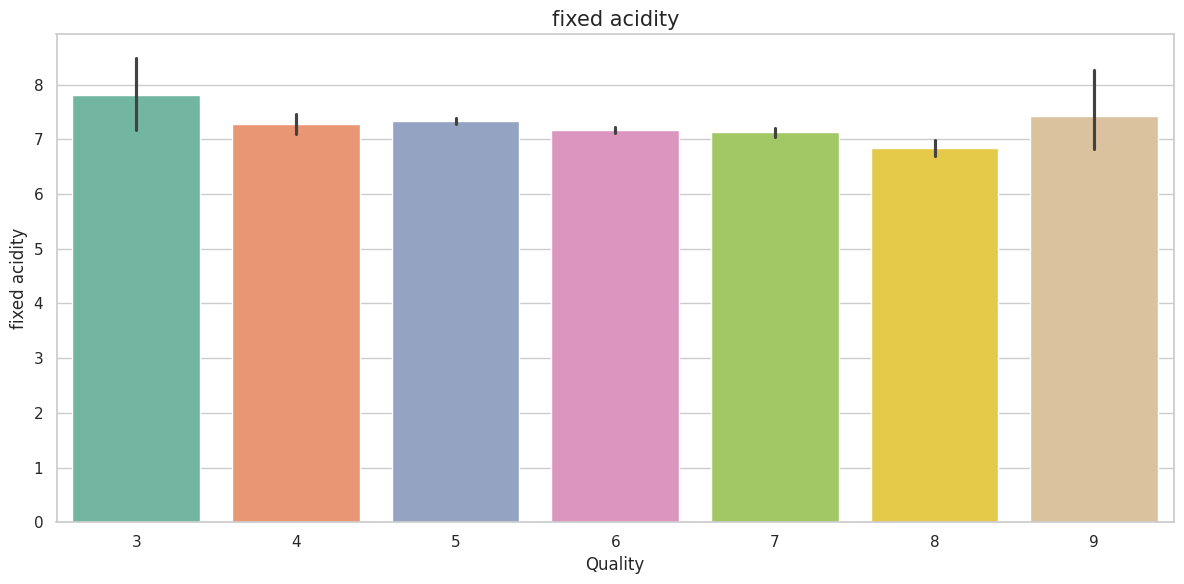

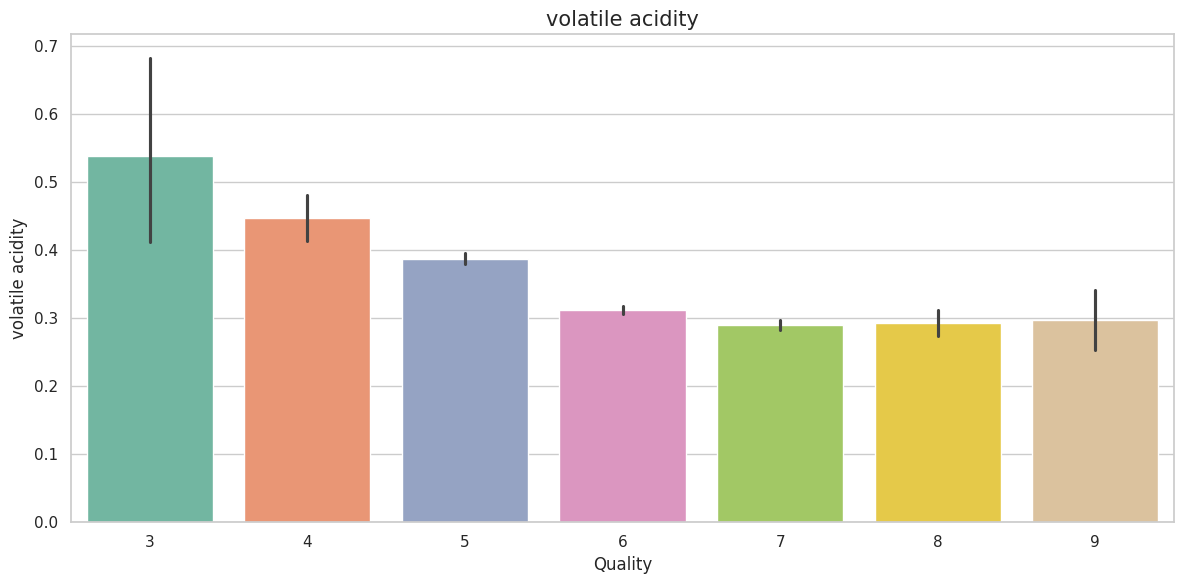

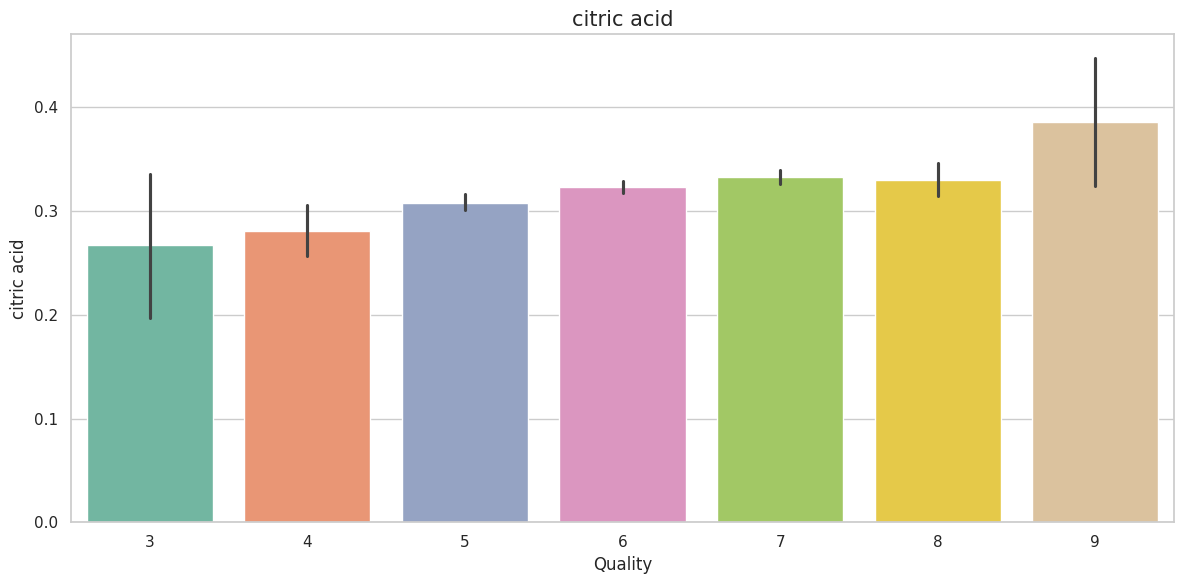

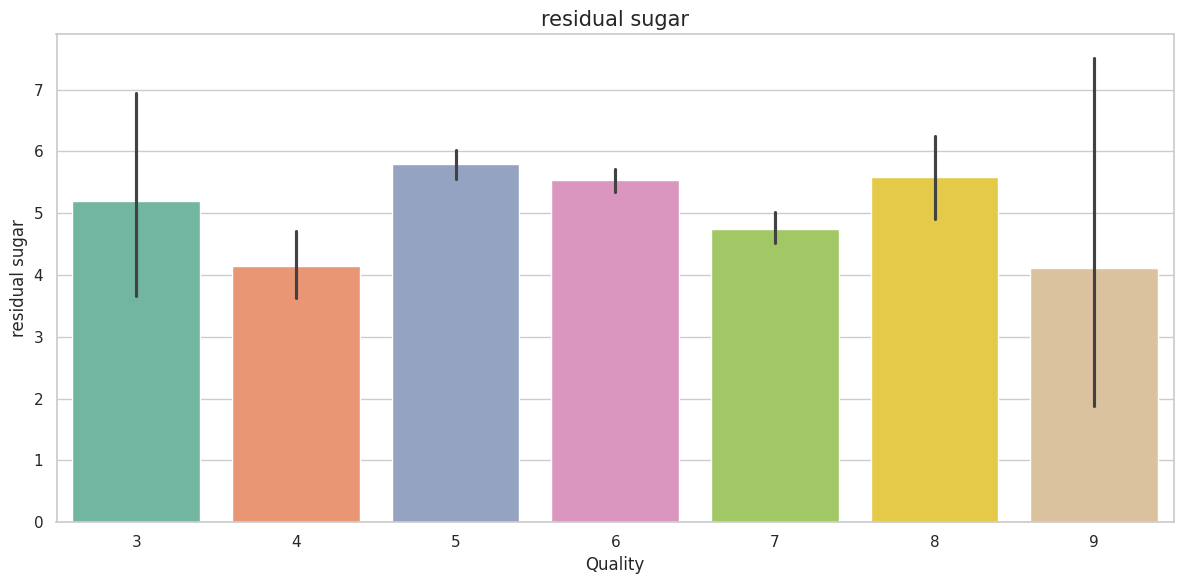

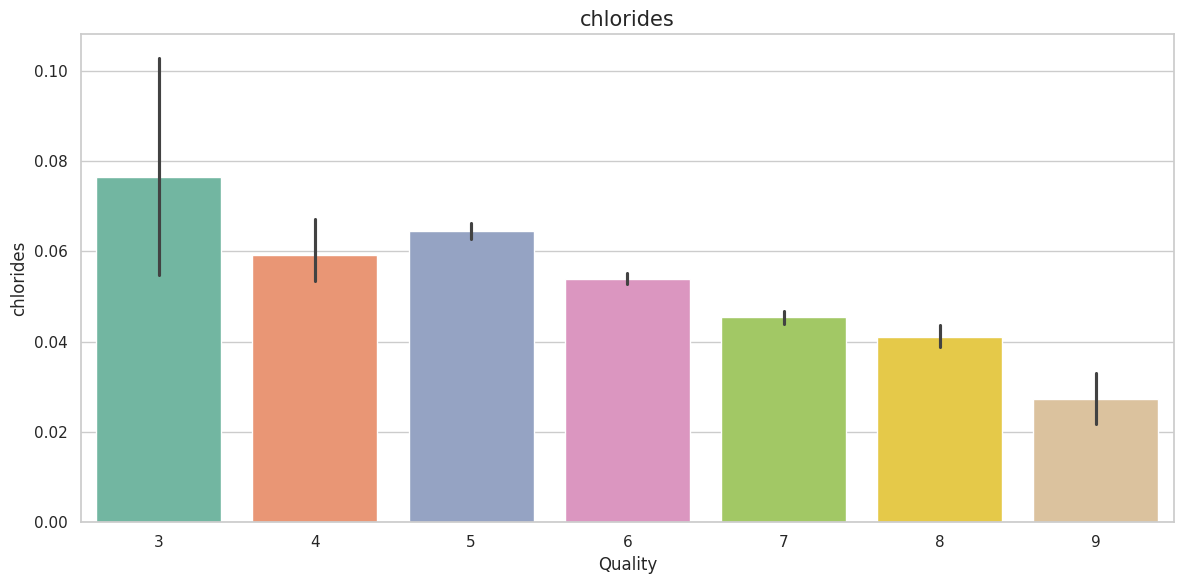

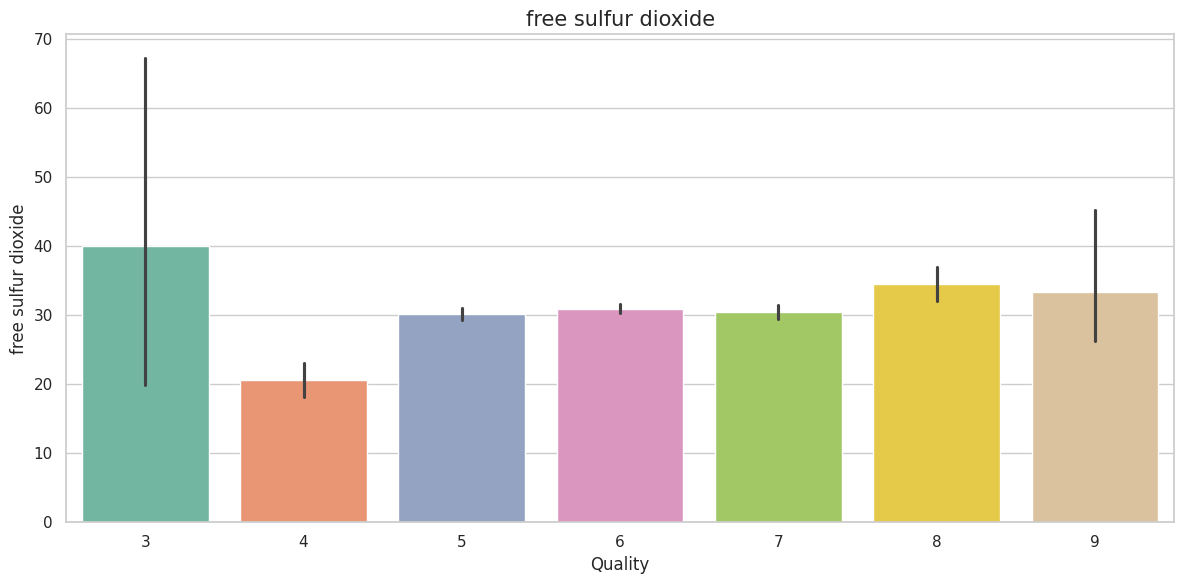

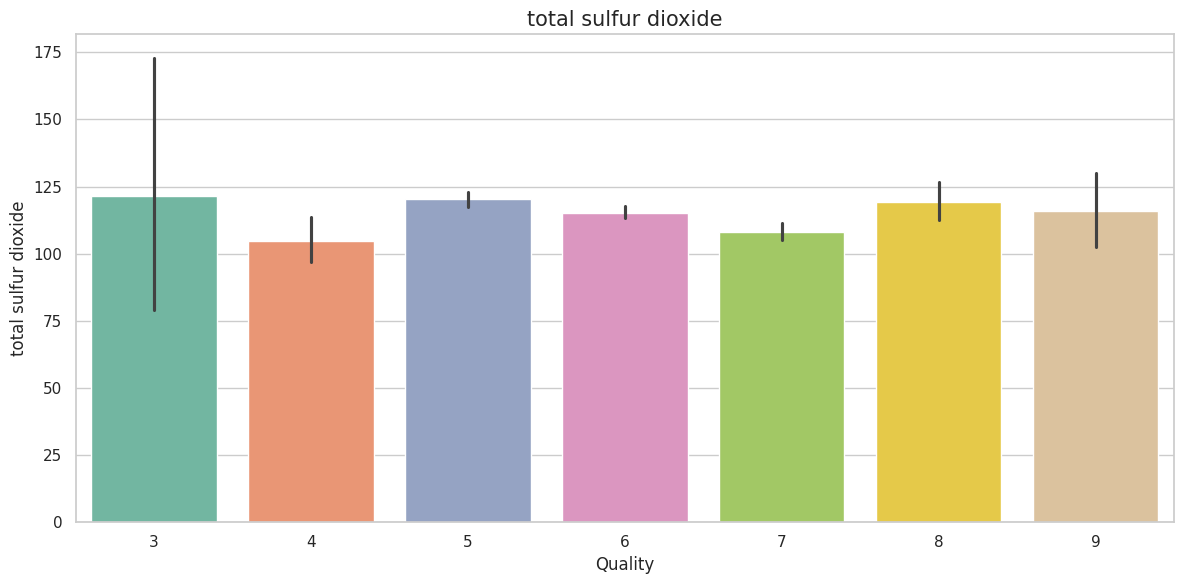

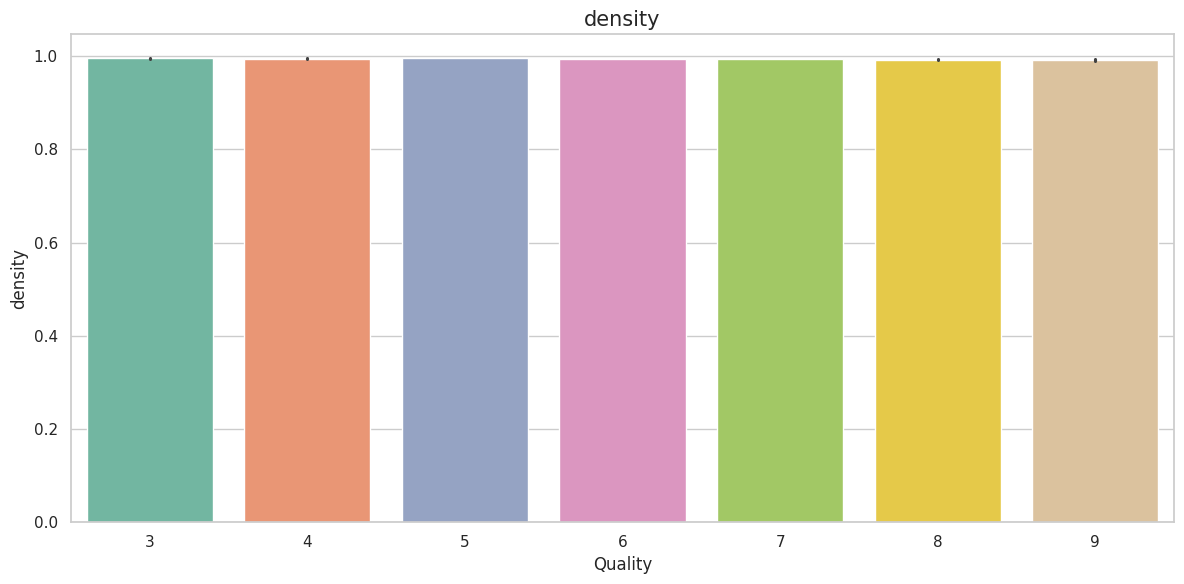

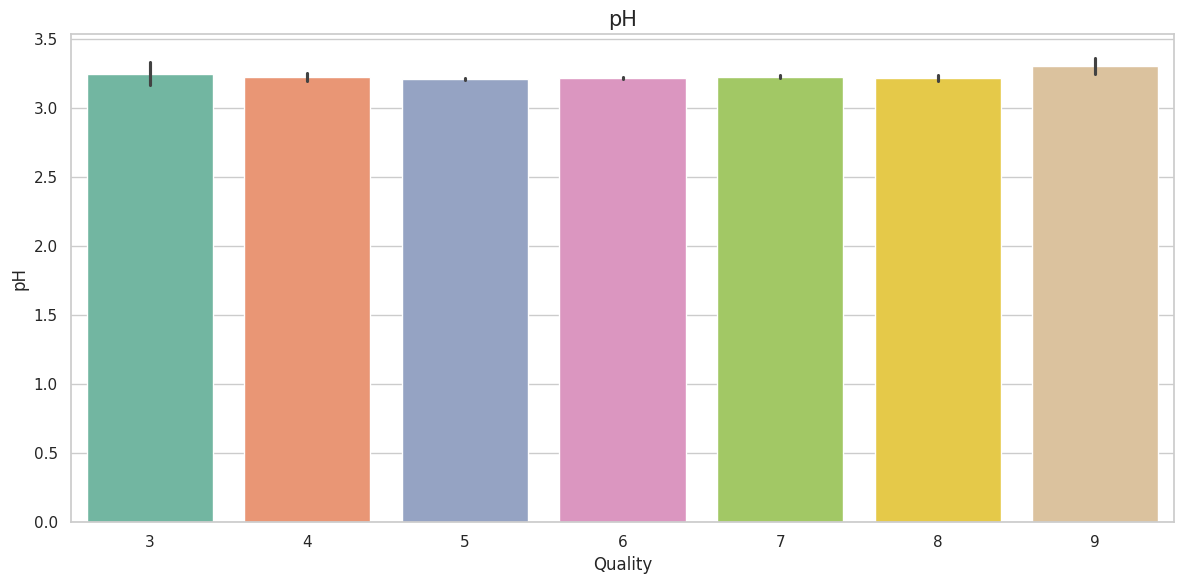

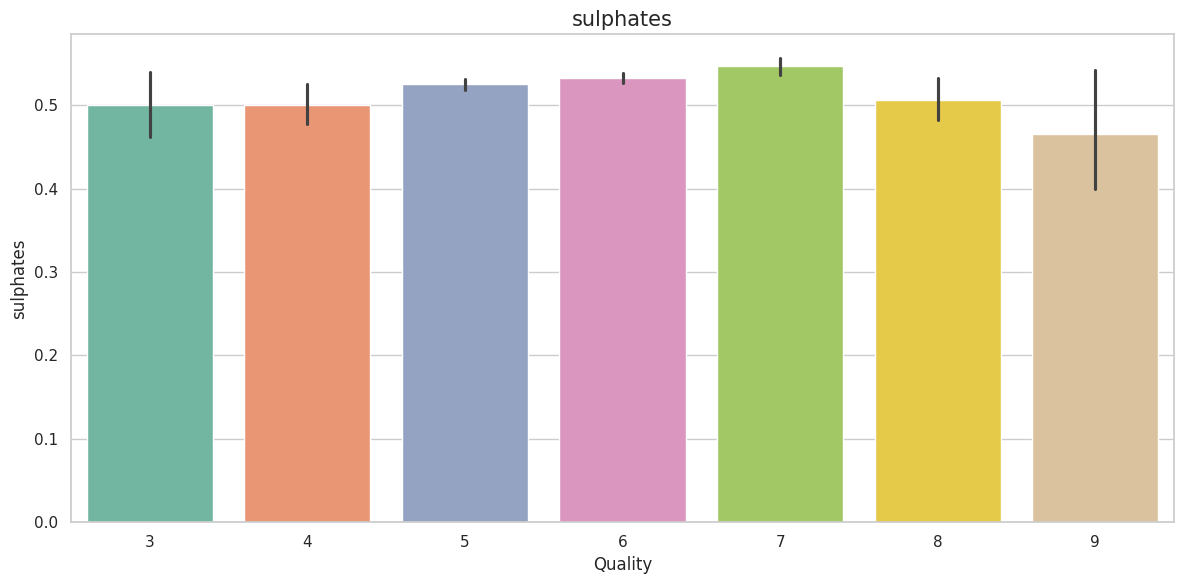

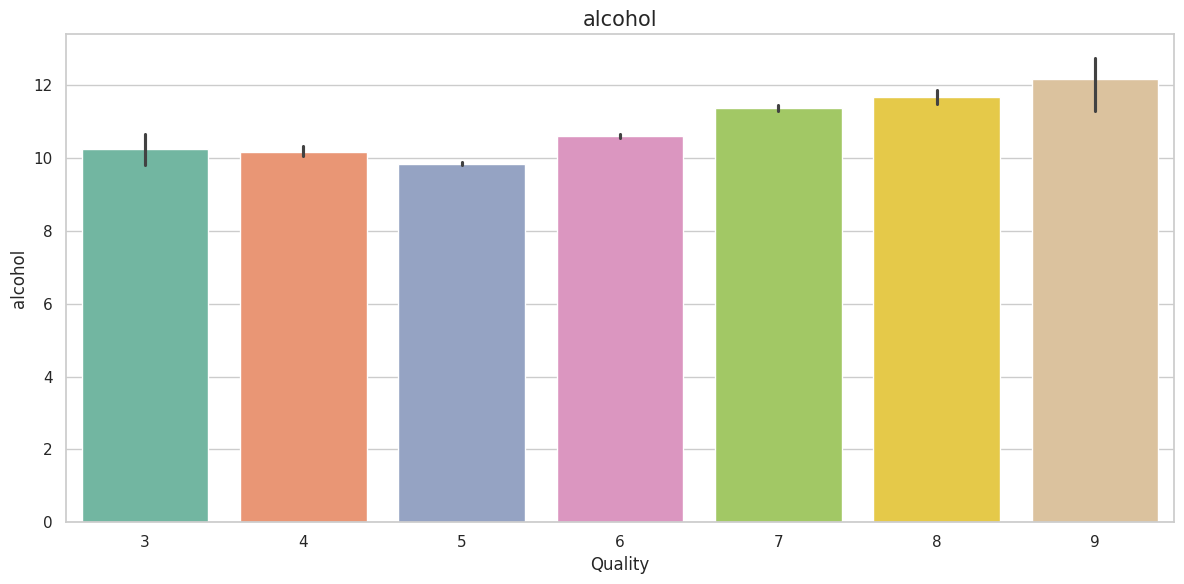

In [ ]:
# train에서 각 변수와 quality 변수 사이 분포를 확인합시다

sns.set(style="whitegrid") # 배경 깔끔하게

for i in range(11):
  plt.figure(figsize  = (12,6))

  sns.barplot(
      x = 'quality',
      y = train.columns[i+2],
      data = train,
      palette = 'Set2' # 컬러풀하게
  )


  plt.title(train.columns[i+2], fontsize=15)
  plt.xlabel('Quality', fontsize=12)
  plt.ylabel(train.columns[i+2], fontsize=12)


  plt.tight_layout()
  plt.show()

데이터 전처리

In [ ]:
# 데이터 전처리를 위해 train과 test 데이터를 다시 로드합니다.
# 이렇게 하면 'type' 컬럼이 다시 'white', 'red' 문자열 상태로 돌아옵니다.
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

In [ ]:
# type에는 white와 red 두 종류가 있습니다
# 각각 0,1로 변환합니다.
# 사용자의 제안에 따라 map 함수를 사용하여 명시적으로 변환합니다.

train['type'] = train['type'].map({'white': 0, 'red': 1})
test['type'] = test['type'].map({'white': 0, 'red': 1})

In [ ]:
# alcohol_density 피처 생성
train['alcohol_density'] = train['alcohol'] / train['density']
test['alcohol_density'] = test['alcohol'] / test['density']

기존 `q--HQ098bqoC` 셀의 기능을 이 위치로 옮겼으므로, 원본 셀을 제거합니다.

In [ ]:
train.head()

,index,quality,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type,alcohol_density
0,0,5,5.6,0.695,0.06,6.8,0.042,9.0,84.0,0.99432,3.44,0.44,10.2,0,10.258267
1,1,5,8.8,0.610,0.14,2.4,0.067,10.0,42.0,0.99690,3.19,0.59,9.5,1,9.529542
2,2,5,7.9,0.210,0.39,2.0,0.057,21.0,138.0,0.99176,3.05,0.52,10.9,0,10.990562
3,3,6,7.0,0.210,0.31,6.0,0.046,29.0,108.0,0.99390,3.26,0.50,10.8,0,10.866284
4,4,6,7.8,0.400,0.26,9.5,0.059,32.0,178.0,0.99550,3.04,0.43,10.9,0,10.949272


In [ ]:
# 불필요한 변수 제거
train_x = train.drop(['index', 'quality'], axis=1)
train_y = train['quality']
test_x = test.drop(['index'], axis=1)

In [ ]:
train_x.shape, train_y.shape, test_x.shape

((5497, 13), (5497,), (1000, 13))

모델링 진행

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# 모델선언
model = RandomForestClassifier()

# 모델학습
model.fit(train_x, train_y)

RandomForestClassifier()

In [ ]:
# 학습화 된 모델로 test 데이터 예측
y_pred = model.predict(test_x)

제출 파일 생성

In [ ]:
submission = pd.read_csv('sample_submission.csv')
submission['quality']=y_pred
submission

,index,quality
0,0,5
1,1,5
2,2,6
3,3,5
4,4,6
...,...,...
995,995,6
996,996,6
997,997,5
998,998,6


In [ ]:
# csv 파일로 저장
submission.to_csv('baseline.csv', index=False)

In [ ]:
# train['alcohol_density'] = train['alcohol'] / train['density']
# test['alcohol_density'] = test['alcohol'] / test['density']
# 기존 기능이 다른 셀로 이동되었으므로 주석 처리 또는 제거합니다.

In [ ]:
from sklearn.model_selection import train_test_split

# 검증 추가

x = train.drop('quality', axis=1)
y = train['quality']

X_train, X_valid, y_train, y_valid = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# 기존 랜덤포레스트 그대로 사용
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

# 검증 점수 확인 (중요)

pred = model.predict(X_valid)
print("Accuracy:", accuracy_score(y_valid, pred))

Accuracy: 0.6436363636363637


In [ ]:
# 제출 재시도
pred_test = model.predict(test)

submission['quality'] = pred_test
submission.to_csv('submission_v2.csv', index=False)

In [ ]:
# 검증 검수 먼저 확인
pred = model.predict(X_valid)
acc = accuracy_score(y_valid, pred)
print("Accuracy:", acc)

Accuracy: 0.6436363636363637


In [ ]:
# 라이브러리 추가

In [ ]:
X = train.drop('quality', axis=1)
y = train['quality']

In [ ]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

랜덤포레스트 모델 만들기

In [ ]:
rf_model = RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.model_selection import cross_val_score

# 교차검증 실행

scores = cross_val_score(rf_model, X, y, cv=skf, scoring='accuracy')

In [ ]:
print("각 폴드 정확도:", scores)
print("평균 정확도:", scores.mean())

각 폴드 정확도: [0.67363636 0.65818182 0.66696997 0.67606915 0.65514104]
평균 정확도: 0.6659996691206882


### 하이퍼파라미터 튜닝: RandomForestClassifier

In [ ]:
from sklearn.model_selection import GridSearchCV

# RandomForestClassifier 모델 정의 (이전에 사용된 model 변수를 사용)
model = RandomForestClassifier(random_state=42)

# 튜닝할 하이퍼파라미터 범위 설정
param_grid = {
    'max_depth': [10, 20, 30, None], # None은 깊이 제한 없음
    'n_estimators': [100, 200, 300]
}

# GridSearchCV 객체 생성
# cv=skf (StratifiedKFold)를 사용하여 클래스 불균형을 고려한 교차 검증 수행
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=skf, scoring='accuracy', n_jobs=-1, verbose=1)

# 데이터 (X, y는 전체 train 데이터)에 Grid Search 수행
grid_search.fit(X, y)

# 최적의 하이퍼파라미터와 최고 점수 출력
print("최적 하이퍼파라미터:", grid_search.best_params_)
print("최고 교차 검증 정확도:", grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
최적 하이퍼파라미터: {'max_depth': None, 'n_estimators': 300}
최고 교차 검증 정확도: 0.6703649598808834


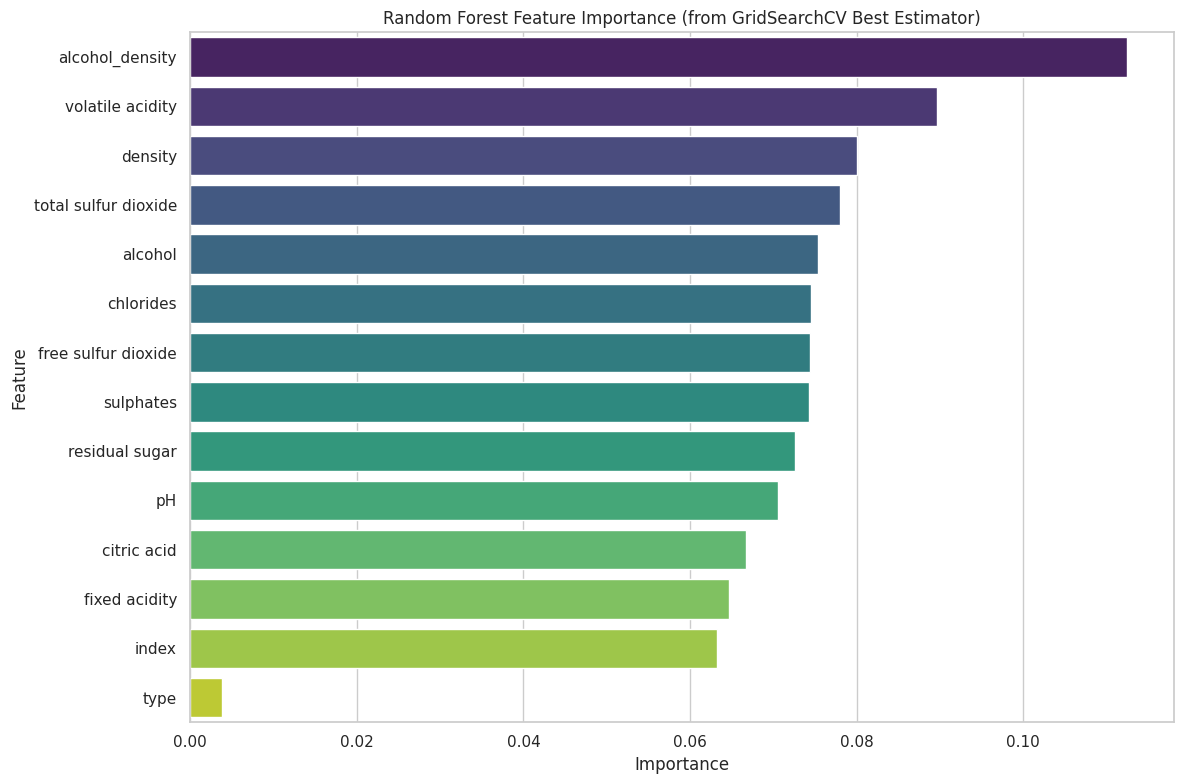

In [ ]:
# 랜덤 포레스트 피처 중요도 추출
# 'model' 변수가 직접 학습되지 않았으므로, GridSearchCV의 최적 모델을 사용합니다.
rf_feature_importances = grid_search.best_estimator_.feature_importances_
# feature_names는 GridSearchCV 학습 시 사용된 X의 컬럼을 사용합니다.
rf_feature_names = X.columns

# 피처 중요도를 데이터프레임으로 생성
rf_importance_df = pd.DataFrame({'Feature': rf_feature_names, 'Importance': rf_feature_importances})

# 중요도 순으로 정렬
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df, palette='viridis')
plt.title('Random Forest Feature Importance (from GridSearchCV Best Estimator)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

LightGBM

In [ ]:
import lightgbm as lgb

### LightGBM 모델 생성 및 교차 검증

In [ ]:
# LightGBM 모델 선언
lgbm_model = lgb.LGBMClassifier(random_state=42)

# 교차 검증 실행
# X와 y는 이전에 정의된 train 데이터의 피처와 타겟 변수입니다.
# skf는 이전에 정의된 StratifiedKFold 객체입니다.
scores_lgbm = cross_val_score(lgbm_model, X, y, cv=skf, scoring='accuracy')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000831 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2005
[LightGBM] [Info] Number of data points in the train set: 4397, number of used features: 14
[LightGBM] [Info] Start training from score -5.344155
[LightGBM] [Info] Start training from score -3.391465
[LightGBM] [Info] Start training from score -1.123248
[LightGBM] [Info] Start training from score -0.821849
[LightGBM] [Info] Start training from score -1.783380
[LightGBM] [Info] Start training from score -3.584657
[LightGBM] [Info] Start training from score -7.002383
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

In [ ]:
print("각 폴드 정확도 (LightGBM):", scores_lgbm)
print("평균 정확도 (LightGBM):", scores_lgbm.mean())

각 폴드 정확도 (LightGBM): [0.63363636 0.65545455 0.65150136 0.63512284 0.62238399]
평균 정확도 (LightGBM): 0.6396198196707751


### LightGBM 모델 피처 중요도 시각화

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000897 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2048
[LightGBM] [Info] Number of data points in the train set: 5497, number of used features: 14
[LightGBM] [Info] Start training from score -5.353861
[LightGBM] [Info] Start training from score -3.386211
[LightGBM] [Info] Start training from score -1.123105
[LightGBM] [Info] Start training from score -0.822089
[LightGBM] [Info] Start training from score -1.783246
[LightGBM] [Info] Start training from score -3.588077
[LightGBM] [Info] Start training from score -7.002520
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

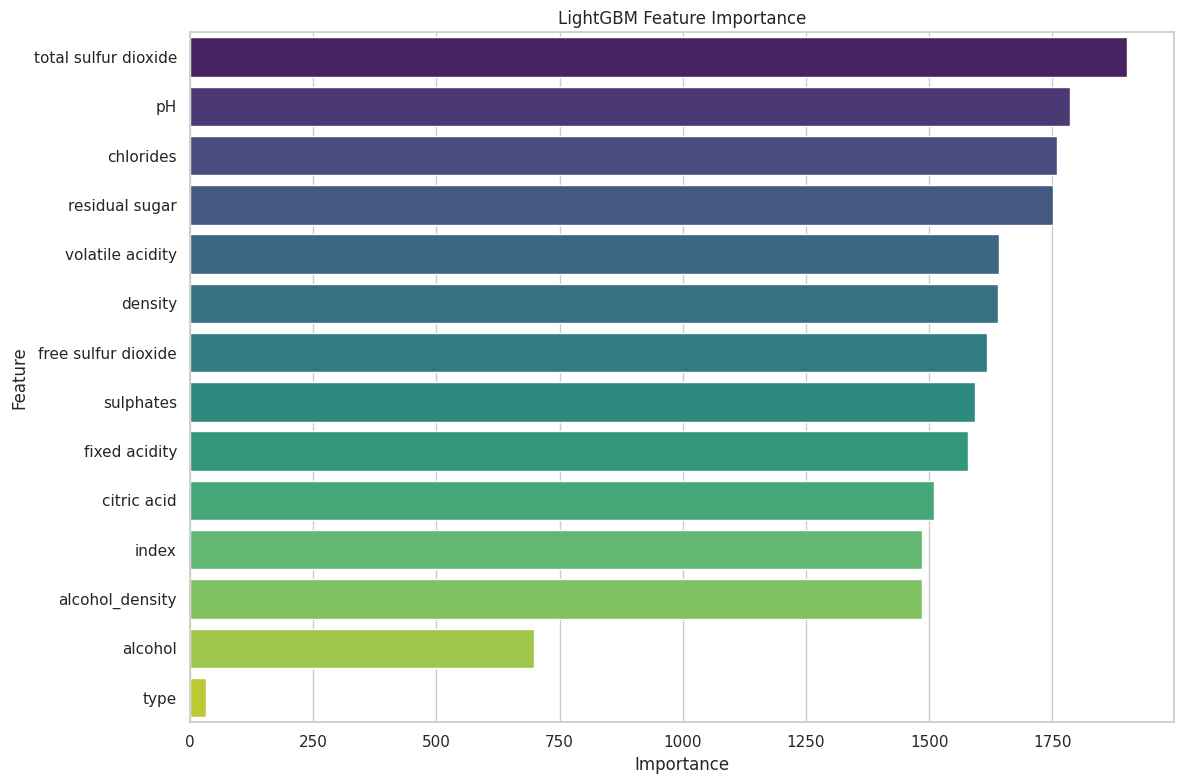

In [ ]:
# 피처 중요도 추출
lgbm_model.fit(X, y) # 모델을 명시적으로 학습시킵니다.
feature_importances = lgbm_model.feature_importances_
feature_names = X.columns # X_lgbm 대신 X를 사용합니다.

# 피처 중요도를 데이터프레임으로 생성
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# 중요도 순으로 정렬
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('LightGBM Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### LightGBM 모델 혼동 행렬 시각화

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001886 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1991
[LightGBM] [Info] Number of data points in the train set: 4397, number of used features: 14
[LightGBM] [Info] Start training from score -5.344155
[LightGBM] [Info] Start training from score -3.384731
[LightGBM] [Info] Start training from score -1.123248
[LightGBM] [Info] Start training from score -0.822367
[LightGBM] [Info] Start training from score -1.783380
[LightGBM] [Info] Start training from score -3.584657
[LightGBM] [Info] Start training from score -7.002383
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

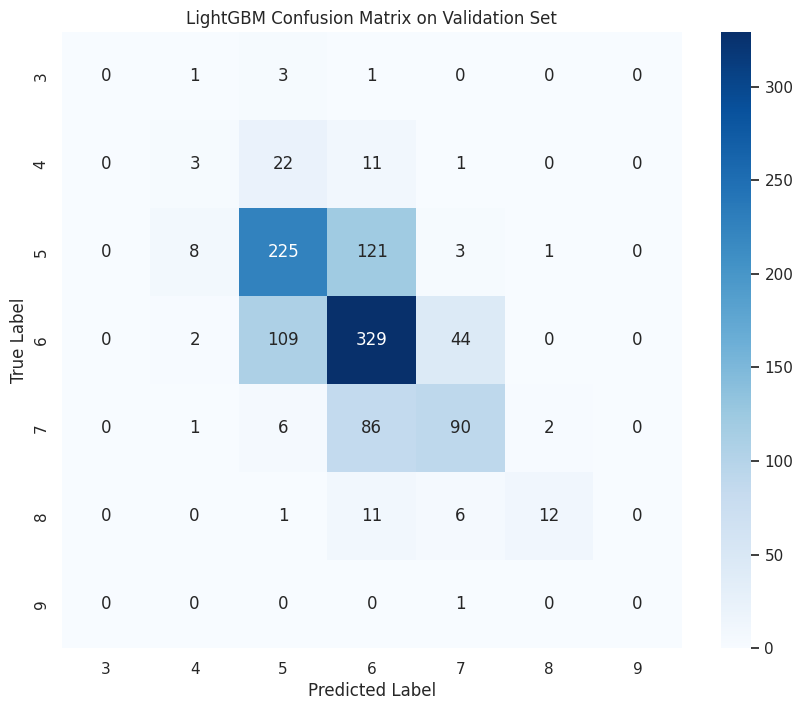

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# lgbm_model을 X_train, y_train으로 다시 학습 (validation split에 맞춰)
lgbm_model_for_cm = lgb.LGBMClassifier(random_state=42)
lgbm_model_for_cm.fit(X_train, y_train)

# X_valid 데이터로 예측 수행
y_pred_lgbm_valid = lgbm_model_for_cm.predict(X_valid)

# 혼동 행렬 계산
cm_lgbm = confusion_matrix(y_valid, y_pred_lgbm_valid)

# 혼동 행렬 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues',
            xticklabels=lgbm_model_for_cm.classes_,
            yticklabels=lgbm_model_for_cm.classes_)
plt.title('LightGBM Confusion Matrix on Validation Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Modeling

In [ ]:
# Labrary
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

In [ ]:
#Standardscaler
ss= StandardScaler()
numerical_columns = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'alcohol_density']

# Fit and transform train data
train.loc[:, numerical_columns] = ss.fit_transform(train[numerical_columns])

# Transform test data manually using the fitted scaler's mean and scale
# This is a workaround if ss.transform directly isn't working as expected for the test DataFrame
for i, col in enumerate(numerical_columns):
    test[col] = (test[col] - ss.mean_[i]) / ss.scale_[i]

# type 변환은 앞서 수행되었으므로, 여기서는 불필요한 factorize 작업을 제거합니다.

print("Scaled Train Data Head:")
print(train.head(3))
print("\nScaled Test Data Head:")
print(test.head(3))

Scaled Train Data Head:
   index  quality  fixed acidity  volatile acidity  citric acid  \
0      0        5      -1.250611          2.186377     -1.78194   
1      1        5       1.234899          1.665574     -1.23056   
2      2        5       0.535849         -0.785265      0.49250   

   residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  \
0        0.286345  -0.398500            -1.211937             -0.560852   
1       -0.638755   0.322998            -1.155351             -1.307080   
2       -0.722855   0.034399            -0.532907              0.398583   

    density        pH  sulphates   alcohol  type  alcohol_density  
0 -0.117252  1.372128  -0.605988 -0.255287     0        -0.249543  
1  0.738864 -0.183584   0.398147 -0.841348     1        -0.844773  
2 -0.966732 -1.054782  -0.070450  0.330774     0         0.348602  

Scaled Test Data Head:
   index  fixed acidity  volatile acidity  citric acid  residual sugar  \
0      0       1.390243         -0.1

- StandardScaler를 통해서 표준화 작업을 진행하였고,
type을 0과 1로 변환해주었습니다.
-  ML에서는 str은 들어가지 않으므로 변환은 꼭 하자
- 이외에도 encoding에는 pd.get_dummies(), labelEncoder 등이 있습니다.

In [ ]:
X = train.drop(['index', 'quality'],axis=1)
y = train.quality

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2, random_state=42)

test_size : 0.2 train과 test를 8:2로 구분한다는 의미!
random_state : 42 같은 값으로 나오게 하기 위한 Seed 설정!

In [ ]:
X_train.shape, X_test.shape

((4397, 13), (1100, 13))

In [ ]:
def Model(model):
    model.fit(X_train,y_train)
    score = model.score(X_test,y_test)
    model_train_score= model.score(X_train,y_train)
    model_test_score=model.score(X_test,y_test)
    prediction = model.predict(X_test)
    cm = confusion_matrix(y_test, prediction)
    print("Testing Score\n", score)
    # plot_confusion_matrix(model,X_test,y_test,cmap='OrRd') # Deprecated function, removed to fix NameError

In [ ]:
#RandomForest
rf= RandomForestClassifier()
rf.fit(X_train,y_train)
Model(rf)

Testing Score
 0.6845454545454546


In [ ]:
# 기본 vs feature 비교코드

# 기본 데이터
X = train.drop('quality', axis=1)
y = train['quality']

# 모델 고정
model = RandomForestClassifier(random_state=42)

# 1. 기본 점수
base_score = cross_val_score(model, X, y, cv=5).mean()
print("기본 점수:", base_score)

기본 점수: 0.6612679295227066


In [ ]:
# 피처가 좋은지 아닌지 점수로 판별하는 테스트 코드

X1 = X.copy()
X1['alcohol_density'] = X1['alcohol'] / X1['density']

score1 = cross_val_score(model, X1, y, cv=5).mean()
print(score1)

0.6681799983456035


- 0.007 상승
- 0.661 → 0.668로 올라갔기 때문에 alcohol_density는 유효한 feature다.

In [ ]:
X2 = X.copy()  # 원본 보호용 복사
X2['sulfur_gap'] = X2['total sulfur dioxide'] - X2['free sulfur dioxide']  # 새 피처
score2 = cross_val_score(model, X2, y, cv=5).mean()  # 5번 검증 평균 점수
print(score2)  # 결과 출력


0.6638152039043759


- 기본: 0.6612
- sulfur_gap: 0.6638
- 애매함


In [ ]:
X3 = X.copy()
X3['acidity_ratio'] = X3['fixed acidity'] / (X3['volatile acidity'] + 1e-6)

score3 = cross_val_score(model, X3, y, cv=5).mean()
print(score3)

0.6667234676151874


acidity_ratio: 0.6645

In [ ]:
X_final = X.copy()
X_final['alcohol_density'] = X_final['alcohol'] / X_final['density']

score_final = cross_val_score(model, X_final, y, cv=5).mean()
print(score_final)

0.6607208205806933


- alcohol_density: 0.6681
- 알코올과 밀도의 관계가 품질 예측에 가장 유의미한 정보였다

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. 최종 데이터 구성 (검증된 feature만)
X_final = train.drop('quality', axis=1).copy()
X_final['alcohol_density'] = X_final['alcohol'] / X_final['density']

y = train['quality']

# test도 동일하게 맞춰야 함
test_final = test.copy()
test_final['alcohol_density'] = test_final['alcohol'] / test_final['density']

# 2. 모델 학습
model = RandomForestClassifier(random_state=42, class_weight='balanced') # class_weight='balanced' 추가
model.fit(X_final, y)

# 3. 예측
pred_test = model.predict(test_final)

# 4. 제출 파일 생성
submission['quality'] = pred_test
submission.to_csv('submission_final.csv', index=False)

feature importance 시각화

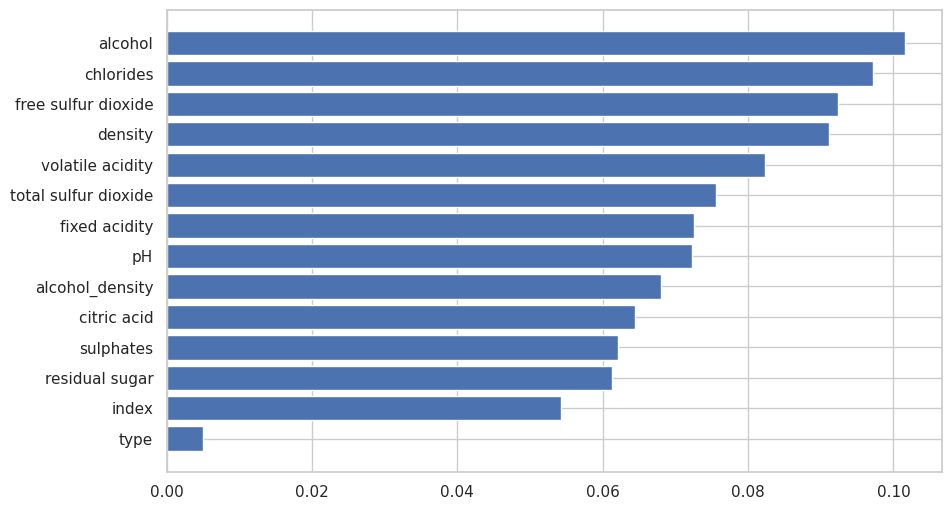

In [ ]:
importance = pd.DataFrame({
    'feature': X_final.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance['feature'], importance['importance'])
plt.gca().invert_yaxis()
plt.show()

feature importance를 확인한 결과, alcohol_density와 alcohol 관련 변수가 높은 중요도를 보여 실제로 품질 예측에 영향을 주는 것을 확인했다/

In [ ]:
from google.colab import files
files.download('submission_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

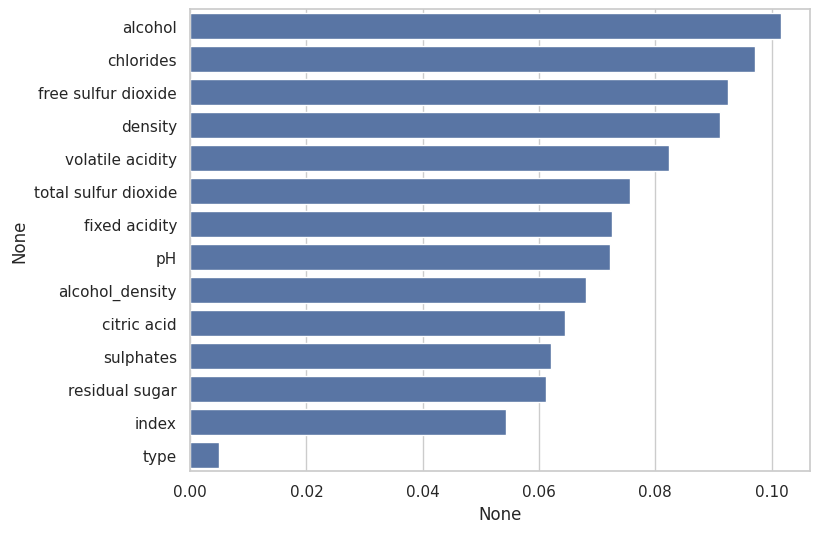

In [ ]:
# model은 사용하신 변수명으로 바꾸세요 (예: rf_model 등)
ftr_importances = pd.Series(model.feature_importances_, index=X.columns)
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]

plt.figure(figsize=(8, 6))
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.show()